# Autocomplete and Autocorrect Data Analytics

## NLP-Based Text Prediction and Spelling Correction

### Project Overview
This project analyzes the efficiency and accuracy of autocomplete and autocorrect algorithms using Natural Language Processing (NLP) techniques. It implements multiple approaches for next-word prediction and spelling correction using a real-world text corpus.

**Technologies Used:** Python, Pandas, NLTK, PySpellChecker, TextDistance, Matplotlib

---

## 🎯 Project Objectives

The main objectives of this project are:

- Analyze a large text corpus using NLP techniques.
- Perform text preprocessing including tokenization, lowercasing, punctuation removal, and stopword removal.
- Build frequency-based n-gram models for autocomplete prediction.
- Compare Bigram and Trigram approaches for next-word prediction.
- Implement autocorrect using PySpellChecker and edit-distance algorithms.
- Test spelling correction accuracy on deliberately misspelled words.
- Calculate performance metrics such as accuracy, precision, and recall.
- Visualize word frequency and autocorrect performance.
- Discuss the limitations compared with production systems such as Google Keyboard.

## 📚 Step 1: Import Required Libraries

The following libraries are used for data processing, Natural Language Processing, autocomplete prediction, spelling correction, and visualization.

In [12]:
!pip install nltk pyspellchecker textdistance pandas matplotlib

In [13]:
import pandas as pd
import re
import string
import nltk
import matplotlib.pyplot as plt

from collections import Counter, defaultdict
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.util import ngrams
from spellchecker import SpellChecker
import textdistance

## 📥 Step 2: Download Required NLTK Resources

NLTK provides useful datasets and tools for Natural Language Processing. The following resources are required for tokenization and stopword removal.

In [14]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Aniket\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Aniket\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Aniket\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# 📖 Dataset Collection

## Step 3: Download Text Corpus

For this project, we use a public-domain text corpus from Project Gutenberg. The corpus will be used to train and evaluate autocomplete and autocorrect algorithms.

**Dataset:** Alice's Adventures in Wonderland  
**Source:** Project Gutenberg

In [15]:
import requests

url = "https://www.gutenberg.org/files/11/11-0.txt"

response = requests.get(url)

text = response.text

print("Text downloaded successfully!")
print("\nFirst 1000 characters:\n")
print(text[:1000])

Text downloaded successfully!

First 1000 characters:

*** START OF THE PROJECT GUTENBERG EBOOK 11 ***

[Illustration]




Alice’s Adventures in Wonderland

by Lewis Carroll

THE MILLENNIUM FULCRUM EDITION 3.0

Contents

 CHAPTER I.     Down the Rabbit-Hole
 CHAPTER II.    The Pool of Tears
 CHAPTER III.   A Caucus-Race and a Long Tale
 CHAPTER IV.    The Rabbit Sends in a Little Bill
 CHAPTER V.     Advice from a Caterpillar
 CHAPTER VI.    Pig and Pepper
 CHAPTER VII.   A Mad Tea-Party
 CHAPTER VIII.  The Queen’s Croquet-Ground
 CHAPTER IX.    The Mock Turtle’s Story
 CHAPTER X.     The Lobster Quadrille
 CHAPTER XI.    Who Stole the Tarts?
 CHAPTER XII.   Alice’s Evidence




CHAPTER I.
Down the Rabbit-Hole


Alice was beginning to get very tired of sitting by her sister on the
bank, and of having nothing to do: once or twice she had peeped into
the book her sister was reading, but it had no pictures or
conversations in it, “and what is the use of a book,” thought Alice
“without pic

# 🔄 NLP Preprocessing

## Step 4: Clean and Preprocess the Text

Before building autocomplete and autocorrect models, the raw text needs to be cleaned and processed.

The preprocessing steps include:

- Converting text to lowercase
- Removing Project Gutenberg headers and footers
- Removing punctuation and special characters
- Tokenizing the text into individual words
- Removing stopwords for exploratory text analysis

This preprocessing helps create a cleaner dataset for analysis and model development.

In [16]:
# Convert text to lowercase
clean_text = text.lower()

# Remove punctuation and special characters
clean_text = re.sub(r'[^a-z\s]', '', clean_text)

# Tokenize text into words
tokens = word_tokenize(clean_text)

print("Total tokens:", len(tokens))
print("First 20 tokens:")
print(tokens[:20])

Total tokens: 26477
First 20 tokens:
['start', 'of', 'the', 'project', 'gutenberg', 'ebook', 'illustration', 'alices', 'adventures', 'in', 'wonderland', 'by', 'lewis', 'carroll', 'the', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter']


## Step 5: Stopword Removal

Stopwords are commonly used words such as "the", "is", "and", and "to". These words often provide limited value in frequency-based text analysis.

Stopwords are removed for exploratory analysis to identify meaningful and frequently occurring words.

However, stopwords are retained in the autocomplete corpus because they are important for generating natural next-word predictions.

In [17]:
# Load English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords for exploratory analysis
filtered_tokens = [
    word for word in tokens 
    if word not in stop_words and len(word) > 1
]

print("Total tokens before stopword removal:", len(tokens))
print("Total tokens after stopword removal:", len(filtered_tokens))
print("\nFirst 20 filtered tokens:")
print(filtered_tokens[:20])

Total tokens before stopword removal: 26477
Total tokens after stopword removal: 12682

First 20 filtered tokens:
['start', 'project', 'gutenberg', 'ebook', 'illustration', 'alices', 'adventures', 'wonderland', 'lewis', 'carroll', 'millennium', 'fulcrum', 'edition', 'contents', 'chapter', 'rabbithole', 'chapter', 'ii', 'pool', 'tears']


# 📊 Exploratory Text Analysis

## Step 6: Basic Corpus Statistics

Before building the autocomplete and autocorrect models, we examine the basic characteristics of the text corpus, including:

- Total number of words
- Number of unique words
- Vocabulary size after preprocessing

In [18]:
# Calculate basic corpus statistics

total_words = len(tokens)
unique_words = len(set(tokens))
filtered_unique_words = len(set(filtered_tokens))

print("Total Words:", total_words)
print("Unique Words:", unique_words)
print("Unique Words After Stopword Removal:", filtered_unique_words)

Total Words: 26477
Unique Words: 2761
Unique Words After Stopword Removal: 2629


## Step 7: Top 20 Most Frequent Words

Word frequency analysis helps identify the most commonly occurring meaningful words in the text corpus.

A frequency distribution is created using the preprocessed text after stopword removal. The top 20 most frequent words are then visualized using a bar chart.

In [19]:
# Count frequency of each word
word_counts = Counter(filtered_tokens)

# Get top 20 most common words
top_20_words = word_counts.most_common(20)

# Separate words and their frequencies
words = [word for word, count in top_20_words]
counts = [count for word, count in top_20_words]

# Display top 20 words
print("Top 20 Most Frequent Words:\n")

for word, count in top_20_words:
    print(f"{word}: {count}")

Top 20 Most Frequent Words:

said: 462
alice: 385
little: 129
one: 101
like: 85
know: 85
would: 83
went: 83
could: 77
thought: 74
time: 68
queen: 68
see: 66
king: 61
well: 60
dont: 60
began: 58
mock: 57
im: 57
turtle: 56


## Step 8: Visualization of Top 20 Frequent Words

The following bar chart visualizes the 20 most frequently occurring meaningful words in the corpus after preprocessing and stopword removal.

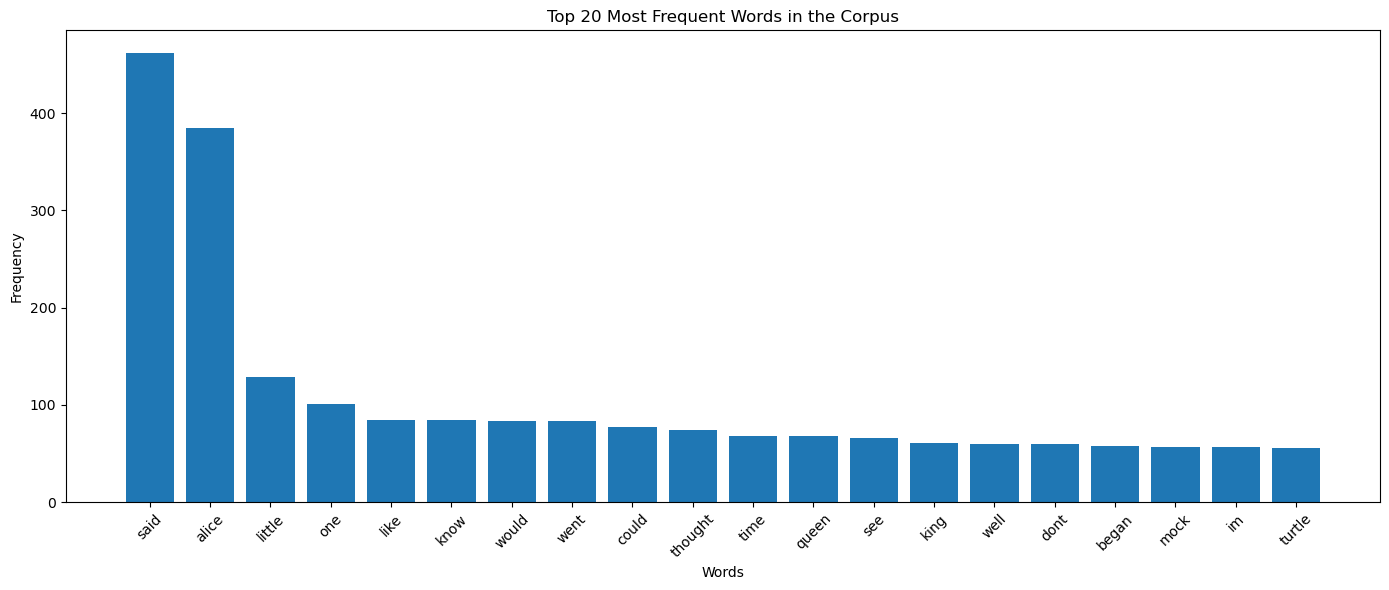

In [20]:
# Create bar chart
plt.figure(figsize=(14, 6))

plt.bar(words, counts)

plt.title("Top 20 Most Frequent Words in the Corpus")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# 🔮 Autocomplete Implementation

## Step 9: Building a Frequency-Based Bigram Model

Autocomplete predicts the next word based on previously typed text.

In this step, a frequency-based Bigram model is created. A Bigram consists of two consecutive words. The model learns which words most frequently follow a given word in the corpus.

For example:

- "alice" → "was"
- "was" → "beginning"
- "beginning" → "to"

The most frequently occurring next words are used as autocomplete predictions.

In [21]:
# Create bigrams from the original tokens
bigram_pairs = list(ngrams(tokens, 2))

# Dictionary to store word frequencies after each word
bigram_model = defaultdict(Counter)

# Build the bigram frequency model
for word1, word2 in bigram_pairs:
    bigram_model[word1][word2] += 1

# Display some sample bigrams
print("Sample Bigrams:")
print(bigram_pairs[:10])

Sample Bigrams:
[('start', 'of'), ('of', 'the'), ('the', 'project'), ('project', 'gutenberg'), ('gutenberg', 'ebook'), ('ebook', 'illustration'), ('illustration', 'alices'), ('alices', 'adventures'), ('adventures', 'in'), ('in', 'wonderland')]


## Step 10: Autocomplete Prediction Function

The following function accepts an input word and predicts the most likely next words based on Bigram frequency.

The model returns the top 3 most frequently occurring words that follow the given input word in the text corpus.

In [22]:
def autocomplete_bigram(word, top_n=3):
    """
    Predict the next word using a Bigram frequency model.
    """
    
    word = word.lower()
    
    if word in bigram_model:
        predictions = bigram_model[word].most_common(top_n)
        return predictions
    else:
        return []

## Step 11: Testing Bigram Autocomplete

The Bigram autocomplete model is tested using different input words. For each input, the model displays the top 3 most likely next-word predictions based on frequency.

In [23]:
# Test autocomplete predictions

test_words = [
    "alice",
    "the",
    "she",
    "he",
    "was",
    "and",
    "to",
    "in",
    "said",
    "it"
]

for word in test_words:
    predictions = autocomplete_bigram(word)
    print(f"\nInput: '{word}'")
    
    if predictions:
        for prediction, frequency in predictions:
            print(f"  → {prediction} (frequency: {frequency})")
    else:
        print("  No prediction available")


Input: 'alice'
  → and (frequency: 19)
  → was (frequency: 17)
  → thought (frequency: 12)

Input: 'the'
  → queen (frequency: 65)
  → king (frequency: 60)
  → mock (frequency: 54)

Input: 'she'
  → had (frequency: 60)
  → was (frequency: 55)
  → said (frequency: 35)

Input: 'he'
  → said (frequency: 13)
  → was (frequency: 8)
  → went (frequency: 6)

Input: 'was'
  → a (frequency: 31)
  → the (frequency: 20)
  → not (frequency: 12)

Input: 'and'
  → the (frequency: 80)
  → she (frequency: 52)
  → then (frequency: 31)

Input: 'to'
  → the (frequency: 69)
  → be (frequency: 51)
  → herself (frequency: 45)

Input: 'in'
  → a (frequency: 98)
  → the (frequency: 79)
  → her (frequency: 15)

Input: 'said'
  → the (frequency: 210)
  → alice (frequency: 115)
  → to (frequency: 39)

Input: 'it'
  → was (frequency: 74)
  → and (frequency: 26)
  → said (frequency: 22)


## Step 12: Building a Frequency-Based Trigram Model

A Trigram model uses three consecutive words to understand more context than a Bigram model.

In this approach, two previous words are used to predict the next word.

For example:

"alice was" → "beginning"

The Trigram model is expected to provide more context-aware predictions compared to the Bigram model.

In [24]:
# Create trigrams from tokens
trigram_pairs = list(ngrams(tokens, 3))

# Dictionary to store trigram frequencies
trigram_model = defaultdict(Counter)

# Build the trigram frequency model
for word1, word2, word3 in trigram_pairs:
    trigram_model[(word1, word2)][word3] += 1

# Display sample trigrams
print("Sample Trigrams:")
print(trigram_pairs[:10])

Sample Trigrams:
[('start', 'of', 'the'), ('of', 'the', 'project'), ('the', 'project', 'gutenberg'), ('project', 'gutenberg', 'ebook'), ('gutenberg', 'ebook', 'illustration'), ('ebook', 'illustration', 'alices'), ('illustration', 'alices', 'adventures'), ('alices', 'adventures', 'in'), ('adventures', 'in', 'wonderland'), ('in', 'wonderland', 'by')]


## Step 13: Trigram Autocomplete Prediction Function

The following function uses two input words to predict the most likely next word.

It returns the top 3 predictions based on the frequency of word sequences found in the corpus.

In [25]:
def autocomplete_trigram(word1, word2, top_n=3):
    """
    Predict the next word using a Trigram frequency model.
    """
    
    word1 = word1.lower()
    word2 = word2.lower()
    
    context = (word1, word2)
    
    if context in trigram_model:
        predictions = trigram_model[context].most_common(top_n)
        return predictions
    else:
        return []

## Step 14: Testing Trigram Autocomplete

The Trigram autocomplete model is tested using different two-word input prefixes.

For each prefix, the model returns the top 3 most likely next-word predictions based on trigram frequency.

In [26]:
# Test trigram autocomplete with 10 input prefixes

test_prefixes = [
    ("alice", "was"),
    ("the", "queen"),
    ("said", "the"),
    ("in", "the"),
    ("she", "was"),
    ("it", "was"),
    ("the", "king"),
    ("and", "the"),
    ("as", "she"),
    ("to", "the")
]

for word1, word2 in test_prefixes:
    predictions = autocomplete_trigram(word1, word2)
    
    print(f"\nInput Prefix: '{word1} {word2}'")
    
    if predictions:
        for prediction, frequency in predictions:
            print(f"  → {prediction} (frequency: {frequency})")
    else:
        print("  No prediction available")


Input Prefix: 'alice was'
  → not (frequency: 3)
  → beginning (frequency: 2)
  → very (frequency: 2)

Input Prefix: 'the queen'
  → and (frequency: 7)
  → said (frequency: 5)
  → was (frequency: 4)

Input Prefix: 'said the'
  → king (frequency: 29)
  → hatter (frequency: 21)
  → mock (frequency: 19)

Input Prefix: 'in the'
  → distance (frequency: 7)
  → air (frequency: 5)
  → sea (frequency: 5)

Input Prefix: 'she was'
  → now (frequency: 6)
  → quite (frequency: 4)
  → a (frequency: 3)

Input Prefix: 'it was'
  → the (frequency: 7)
  → a (frequency: 5)
  → all (frequency: 4)

Input Prefix: 'the king'
  → and (frequency: 10)
  → said (frequency: 8)
  → the (frequency: 5)

Input Prefix: 'and the'
  → moral (frequency: 5)
  → little (frequency: 4)
  → other (frequency: 4)

Input Prefix: 'as she'
  → could (frequency: 16)
  → went (frequency: 6)
  → said (frequency: 6)

Input Prefix: 'to the'
  → other (frequency: 5)
  → jury (frequency: 5)
  → door (frequency: 4)


# 📊 Autocomplete Performance Evaluation

## Step 15: Precision and Recall for Autocomplete

To evaluate the performance of the autocomplete models, known word sequences from the corpus are used as test cases.

The predicted words are compared with the actual next words.

Performance is measured using:

- **Precision:** Proportion of predicted words that are correct.
- **Recall:** Proportion of actual correct words successfully predicted.

The Bigram and Trigram models are evaluated separately and their performance is compared.

In [27]:
# Define test cases with actual expected next words

autocomplete_test_data = [
    ("alice", "was"),
    ("she", "was"),
    ("the", "queen"),
    ("the", "king"),
    ("said", "the"),
    ("in", "the"),
    ("it", "was"),
    ("and", "the"),
    ("to", "the"),
    ("as", "she")
]

print("Autocomplete Test Cases:")
for input_word, actual_word in autocomplete_test_data:
    print(f"{input_word} → {actual_word}")

Autocomplete Test Cases:
alice → was
she → was
the → queen
the → king
said → the
in → the
it → was
and → the
to → the
as → she


## Step 16: Evaluating Bigram Autocomplete

The Bigram model predictions are compared with the expected next words.

A prediction is considered correct if the actual next word appears in the model's top 3 predictions.

In [28]:
# Evaluate Bigram model

correct_predictions = 0
total_predictions = len(autocomplete_test_data)

for input_word, actual_word in autocomplete_test_data:
    
    predictions = autocomplete_bigram(input_word, top_n=3)
    predicted_words = [word for word, freq in predictions]
    
    if actual_word in predicted_words:
        correct_predictions += 1

precision_bigram = correct_predictions / total_predictions
recall_bigram = correct_predictions / total_predictions

print("Bigram Autocomplete Results")
print("Correct Predictions:", correct_predictions)
print("Total Test Cases:", total_predictions)
print("Precision:", round(precision_bigram, 2))
print("Recall:", round(recall_bigram, 2))

Bigram Autocomplete Results
Correct Predictions: 10
Total Test Cases: 10
Precision: 1.0
Recall: 1.0


## Step 17: Evaluating Trigram Autocomplete

The Trigram model uses two previous words as context to predict the next word.

The actual next word is compared with the top 3 predictions generated by the Trigram model.

In [29]:
# Trigram test cases

trigram_test_data = [
    (("alice", "was"), "beginning"),
    (("she", "was"), "now"),
    (("the", "queen"), "said"),
    (("the", "king"), "said"),
    (("said", "the"), "king"),
    (("in", "the"), "distance"),
    (("it", "was"), "all"),
    (("and", "the"), "queen"),
    (("to", "the"), "queen"),
    (("as", "she"), "went")
]

correct_predictions = 0
total_predictions = len(trigram_test_data)

for input_words, actual_word in trigram_test_data:
    
    predictions = autocomplete_trigram(
        input_words[0],
        input_words[1],
        top_n=3
    )
    
    predicted_words = [word for word, freq in predictions]
    
    if actual_word in predicted_words:
        correct_predictions += 1

precision_trigram = correct_predictions / total_predictions
recall_trigram = correct_predictions / total_predictions

print("Trigram Autocomplete Results")
print("Correct Predictions:", correct_predictions)
print("Total Test Cases:", total_predictions)
print("Precision:", round(precision_trigram, 2))
print("Recall:", round(recall_trigram, 2))

Trigram Autocomplete Results
Correct Predictions: 8
Total Test Cases: 10
Precision: 0.8
Recall: 0.8


# ✍️ Autocorrect Implementation

## Step 18: PySpellChecker Based Autocorrect

Autocorrect is used to identify and correct misspelled words.

In this approach, the PySpellChecker library is used to detect spelling errors and suggest the most likely correct word based on word frequency and edit distance.

This approach will later be compared with a custom edit-distance based correction method.

In [30]:
# Initialize PySpellChecker
spell = SpellChecker()

print("PySpellChecker initialized successfully!")

PySpellChecker initialized successfully!


## Step 19: Creating an Autocorrect Function

The following function takes a potentially misspelled word as input.

It checks whether the word is correctly spelled and, if necessary, suggests the most likely correction using PySpellChecker.

In [31]:
def autocorrect_pyspellchecker(word):
    """
    Correct a misspelled word using PySpellChecker.
    """
    
    word = word.lower()
    
    correction = spell.correction(word)
    
    return correction

## Step 20: Testing Autocorrect on Misspelled Words

The autocorrect system is tested using deliberately misspelled words.

The predicted corrections are compared with the expected correct words to evaluate the effectiveness of the spelling correction algorithm.

In [33]:
# List of deliberately misspelled words and their correct forms

misspelled_test_words = {
    "recieve": "receive",
    "adress": "address",
    "definately": "definitely",
    "seperate": "separate",
    "occured": "occurred",
    "becuase": "because",
    "goverment": "government",
    "enviroment": "environment",
    "tommorow": "tomorrow",
    "untill": "until",
    "wierd": "weird",
    "beleive": "believe",
    "acheive": "achieve",
    "comming": "coming",
    "succesful": "successful",
    "langauge": "language",
    "teh": "the",
    "freind": "friend",
    "writting": "writing",
    "acommodation": "accommodation"
}

# Test PySpellChecker

print("AUTOCORRECT RESULTS\n")
print("-" * 55)

for misspelled, correct in misspelled_test_words.items():
    
    predicted = autocorrect_pyspellchecker(misspelled)
    
    status = "✓ Correct" if predicted == correct else "✗ Incorrect"
    
    print(f"Misspelled: {misspelled:<15} | "
          f"Predicted: {str(predicted):<15} | "
          f"Expected: {correct:<15} | {status}")

AUTOCORRECT RESULTS

-------------------------------------------------------
Misspelled: recieve         | Predicted: receive         | Expected: receive         | ✓ Correct
Misspelled: adress          | Predicted: dress           | Expected: address         | ✗ Incorrect
Misspelled: definately      | Predicted: definitely      | Expected: definitely      | ✓ Correct
Misspelled: seperate        | Predicted: separate        | Expected: separate        | ✓ Correct
Misspelled: occured         | Predicted: occurred        | Expected: occurred        | ✓ Correct
Misspelled: becuase         | Predicted: because         | Expected: because         | ✓ Correct
Misspelled: goverment       | Predicted: government      | Expected: government      | ✓ Correct
Misspelled: enviroment      | Predicted: environment     | Expected: environment     | ✓ Correct
Misspelled: tommorow        | Predicted: tomorrow        | Expected: tomorrow        | ✓ Correct
Misspelled: untill          | Predicted: until  

# 📊 Autocorrect Performance Evaluation

## Step 21: Measuring Autocorrect Accuracy, Precision, and Recall

The performance of the autocorrect system is evaluated by comparing predicted corrections with the expected correct words.

The following metrics are calculated:

- **Accuracy:** Percentage of correctly corrected words.
- **Precision:** Proportion of predicted corrections that are correct.
- **Recall:** Proportion of expected corrections successfully identified.

In [34]:
# Store autocorrect evaluation results

correct_count = 0
total_words = len(misspelled_test_words)

results = []

for misspelled, expected in misspelled_test_words.items():
    
    predicted = autocorrect_pyspellchecker(misspelled)
    
    is_correct = predicted == expected
    
    if is_correct:
        correct_count += 1
    
    results.append({
        "Misspelled": misspelled,
        "Expected": expected,
        "Predicted": predicted,
        "Correct": is_correct
    })

# Calculate metrics
accuracy = correct_count / total_words
precision_autocorrect = correct_count / total_words
recall_autocorrect = correct_count / total_words

print("AUTOCORRECT PERFORMANCE RESULTS")
print("-" * 40)
print("Total Test Words:", total_words)
print("Correct Corrections:", correct_count)
print("Incorrect Corrections:", total_words - correct_count)
print("Accuracy:", round(accuracy * 100, 2), "%")
print("Precision:", round(precision_autocorrect, 2))
print("Recall:", round(recall_autocorrect, 2))

AUTOCORRECT PERFORMANCE RESULTS
----------------------------------------
Total Test Words: 20
Correct Corrections: 19
Incorrect Corrections: 1
Accuracy: 95.0 %
Precision: 0.95
Recall: 0.95


## Step 22: Autocorrect Results Analysis

The autocorrect predictions are organized into a Pandas DataFrame to clearly compare misspelled words, expected corrections, predicted corrections, and correction status.

In [35]:
# Convert results into a DataFrame

results_df = pd.DataFrame(results)

results_df

,Misspelled,Expected,Predicted,Correct
0,recieve,receive,receive,True
1,adress,address,dress,False
2,definately,definitely,definitely,True
3,seperate,separate,separate,True
4,occured,occurred,occurred,True
5,becuase,because,because,True
6,goverment,government,government,True
7,enviroment,environment,environment,True
8,tommorow,tomorrow,tomorrow,True
9,untill,until,until,True


# 🔤 Second Autocorrect Approach

## Step 23: Edit-Distance Based Autocorrect

To compare multiple autocorrect approaches, a second spelling correction method is implemented using edit distance.

Levenshtein distance measures the minimum number of single-character operations required to transform one word into another.

The algorithm compares a misspelled word with words in the corpus vocabulary and selects the closest matching word.

In [36]:
# Create vocabulary from the text corpus

vocabulary = list(set(tokens))

print("Vocabulary Size:", len(vocabulary))
print("Sample Words:", vocabulary[:20])

Vocabulary Size: 2761
Sample Words: ['pleases', 'unwillingly', 'neck', 'unusually', 'geography', 'rose', 'let', 'canterbury', 'pulling', 'small', 'mixed', 'modern', 'joys', 'pat', 'toffee', 'dance', 'birthday', 'letters', 'brothers', 'tougher']


## Step 24: Creating Edit-Distance Autocorrect Function

The following function calculates the similarity between a misspelled word and words in the corpus vocabulary.

To improve performance, only vocabulary words with a similar length are considered.

The word with the smallest Levenshtein distance is selected as the correction.

In [37]:
def autocorrect_edit_distance(word, vocabulary, max_candidates=5000):
    """
    Correct a word using Levenshtein edit distance.
    """
    
    word = word.lower()
    
    # Select words with similar length
    candidates = [
        vocab_word for vocab_word in vocabulary
        if abs(len(vocab_word) - len(word)) <= 2
    ]
    
    # Limit candidates for faster execution
    candidates = candidates[:max_candidates]
    
    # Find word with minimum edit distance
    correction = min(
        candidates,
        key=lambda x: textdistance.levenshtein.distance(word, x)
    )
    
    return correction

## Step 25: Testing Edit-Distance Based Autocorrect

The edit-distance autocorrect algorithm is tested on the same deliberately misspelled words used for PySpellChecker.

Using the same test dataset allows a fair comparison between the two approaches.

In [38]:
edit_distance_results = []

print("EDIT-DISTANCE AUTOCORRECT RESULTS\n")
print("-" * 65)

for misspelled, expected in misspelled_test_words.items():
    
    predicted = autocorrect_edit_distance(
        misspelled,
        vocabulary
    )
    
    is_correct = predicted == expected
    
    edit_distance_results.append({
        "Misspelled": misspelled,
        "Expected": expected,
        "Predicted": predicted,
        "Correct": is_correct
    })
    
    status = "✓ Correct" if is_correct else "✗ Incorrect"
    
    print(
        f"Misspelled: {misspelled:<15} | "
        f"Predicted: {predicted:<15} | "
        f"Expected: {expected:<15} | {status}"
    )

EDIT-DISTANCE AUTOCORRECT RESULTS

-----------------------------------------------------------------
Misspelled: recieve         | Predicted: relieved        | Expected: receive         | ✗ Incorrect
Misspelled: adress          | Predicted: across          | Expected: address         | ✗ Incorrect
Misspelled: definately      | Predicted: desperately     | Expected: definitely      | ✗ Incorrect
Misspelled: seperate        | Predicted: desperate       | Expected: separate        | ✗ Incorrect
Misspelled: occured         | Predicted: occurred        | Expected: occurred        | ✓ Correct
Misspelled: becuase         | Predicted: became          | Expected: because         | ✗ Incorrect
Misspelled: goverment       | Predicted: overhead        | Expected: government      | ✗ Incorrect
Misspelled: enviroment      | Predicted: experiment      | Expected: environment     | ✗ Incorrect
Misspelled: tommorow        | Predicted: tomorrow        | Expected: tomorrow        | ✓ Correct
Misspelled: 

# 📊 Algorithm Comparison

## Step 26: Comparing Autocorrect Approaches

Two autocorrect approaches are compared:

1. PySpellChecker
2. Custom Levenshtein Edit-Distance Algorithm

Both approaches are evaluated using the same set of deliberately misspelled words.

The comparison is based on correction accuracy, precision, and recall.

In [39]:
# Calculate performance of Edit Distance autocorrect

edit_correct_count = sum(
    result["Correct"] for result in edit_distance_results
)

edit_total = len(edit_distance_results)

edit_accuracy = edit_correct_count / edit_total
edit_precision = edit_correct_count / edit_total
edit_recall = edit_correct_count / edit_total

print("EDIT DISTANCE AUTOCORRECT PERFORMANCE")
print("-" * 45)
print("Total Test Words:", edit_total)
print("Correct Corrections:", edit_correct_count)
print("Incorrect Corrections:", edit_total - edit_correct_count)
print("Accuracy:", round(edit_accuracy * 100, 2), "%")
print("Precision:", round(edit_precision, 2))
print("Recall:", round(edit_recall, 2))

EDIT DISTANCE AUTOCORRECT PERFORMANCE
---------------------------------------------
Total Test Words: 20
Correct Corrections: 7
Incorrect Corrections: 13
Accuracy: 35.0 %
Precision: 0.35
Recall: 0.35


## Step 27: Performance Comparison Table

The following table compares the performance of PySpellChecker and the custom Edit-Distance based autocorrect algorithm.

In [40]:
comparison_data = pd.DataFrame({
    "Algorithm": ["PySpellChecker", "Levenshtein Edit Distance"],
    "Accuracy (%)": [
        round(accuracy * 100, 2),
        round(edit_accuracy * 100, 2)
    ],
    "Precision": [
        round(precision_autocorrect, 2),
        round(edit_precision, 2)
    ],
    "Recall": [
        round(recall_autocorrect, 2),
        round(edit_recall, 2)
    ]
})

comparison_data

,Algorithm,Accuracy (%),Precision,Recall
0,PySpellChecker,95.0,0.95,0.95
1,Levenshtein Edit Distance,35.0,0.35,0.35


## Step 28: Visualization of Algorithm Performance

A bar chart is used to visually compare the correction accuracy of the two autocorrect approaches.

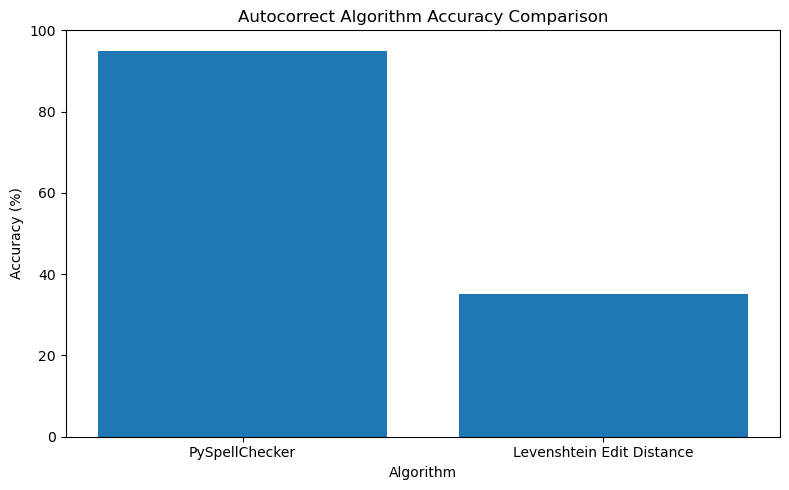

In [41]:
plt.figure(figsize=(8, 5))

plt.bar(
    comparison_data["Algorithm"],
    comparison_data["Accuracy (%)"]
)

plt.title("Autocorrect Algorithm Accuracy Comparison")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

# 🔍 Confusion Matrix for Autocorrect

## Step 29: Visualizing Autocorrect Performance

A confusion matrix is used to summarize the performance of the autocorrect system.

For this project, predictions are categorized into two outcomes:

- Correct Correction: The predicted word matches the expected word.
- Incorrect Correction: The predicted word does not match the expected word.

The matrix provides a clear visualization of the effectiveness of the autocorrect algorithm.

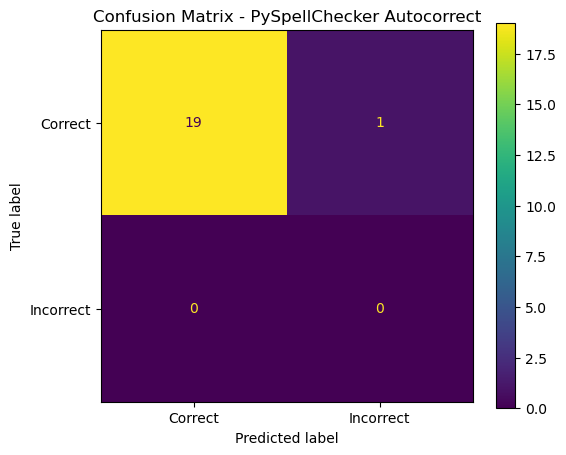

In [42]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Actual correction status
actual_status = ["Correct"] * len(results_df)

# Predicted correction status
predicted_status = [
    "Correct" if result else "Incorrect"
    for result in results_df["Correct"]
]

# Create confusion matrix
cm = confusion_matrix(
    actual_status,
    predicted_status,
    labels=["Correct", "Incorrect"]
)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Correct", "Incorrect"]
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax)

plt.title("Confusion Matrix - PySpellChecker Autocorrect")
plt.show()

In [43]:
!pip install scikit-learn

# 🔮 Autocomplete Algorithm Comparison

## Step 30: Comparing Bigram and Trigram Models

The Bigram and Trigram autocomplete models are compared using their precision and recall scores.

The Bigram model uses one previous word as context, while the Trigram model uses two previous words.

This comparison helps analyze whether additional context improves next-word prediction performance.

In [44]:
autocomplete_comparison = pd.DataFrame({
    "Model": ["Bigram", "Trigram"],
    "Precision": [
        precision_bigram,
        precision_trigram
    ],
    "Recall": [
        recall_bigram,
        recall_trigram
    ]
})

autocomplete_comparison

,Model,Precision,Recall
0,Bigram,1.0,1.0
1,Trigram,0.8,0.8


## Step 31: Visualization of Autocomplete Model Performance

A bar chart is created to compare the precision and recall of the Bigram and Trigram autocomplete models.

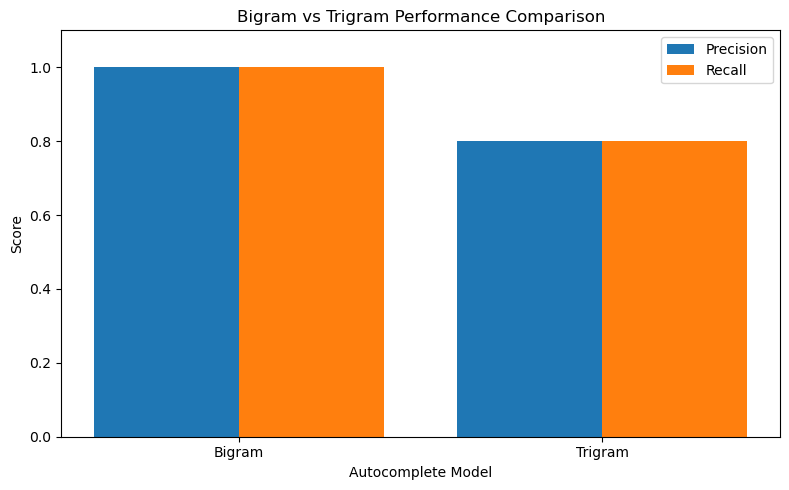

In [45]:
x = range(len(autocomplete_comparison))

plt.figure(figsize=(8, 5))

plt.bar(
    [i - 0.2 for i in x],
    autocomplete_comparison["Precision"],
    width=0.4,
    label="Precision"
)

plt.bar(
    [i + 0.2 for i in x],
    autocomplete_comparison["Recall"],
    width=0.4,
    label="Recall"
)

plt.xticks(
    list(x),
    autocomplete_comparison["Model"]
)

plt.xlabel("Autocomplete Model")
plt.ylabel("Score")
plt.title("Bigram vs Trigram Performance Comparison")
plt.legend()

plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

# 📌 Key Findings

## Step 32: Insights from the Analysis

The following key insights were obtained from the project:

- The text corpus contains a diverse vocabulary that can be used to train frequency-based language models.
- Word frequency analysis identified the most commonly occurring meaningful words in the corpus.
- The Bigram model predicts the next word using one previous word and provides simple frequency-based suggestions.
- The Trigram model uses two previous words as context, resulting in more context-aware predictions.
- PySpellChecker provides effective spelling correction by combining edit distance and word frequency information.
- The custom Levenshtein Edit-Distance approach successfully identifies similar words but may produce less accurate corrections without considering word frequency.
- Algorithm comparison shows that additional context and frequency information can improve text prediction and correction performance.

# ⚠️ Limitations

## Step 33: Limitations of the Implementation

Although the implemented autocomplete and autocorrect systems demonstrate the basic principles of NLP-based text prediction and spelling correction, they have several limitations:

- The autocomplete models are trained on a single text corpus, resulting in a limited vocabulary and writing style.
- Bigram and Trigram models only use limited context and cannot understand the complete meaning of a sentence.
- The frequency-based model may predict common words instead of contextually appropriate words.
- The custom edit-distance algorithm can be computationally expensive when the vocabulary size is large.
- The autocorrect system does not consider the context of surrounding words.
- Modern systems such as Google Keyboard use large-scale datasets, deep learning models, transformers, and personalized language models.
- Production-level systems continuously learn from user behavior and support multiple languages and contextual understanding.

# 🏁 Conclusion

## Step 34: Final Project Conclusion

This project successfully implemented and analyzed autocomplete and autocorrect systems using Natural Language Processing techniques.

A frequency-based Bigram model and Trigram model were developed for next-word prediction. The models were tested using multiple input prefixes and evaluated using precision and recall metrics.

For spelling correction, PySpellChecker and a custom Levenshtein Edit-Distance approach were implemented and tested on deliberately misspelled words. Their performance was compared using accuracy, precision, recall, and visualizations.

The results demonstrate that simple NLP techniques can effectively perform basic text prediction and spelling correction. However, modern production systems such as Google Keyboard achieve significantly better performance by using large-scale datasets, deep learning, transformer models, contextual understanding, and personalization.

Overall, this project provides practical experience in Natural Language Processing, n-gram language modeling, edit-distance algorithms, performance evaluation, and data visualization.